Start from the Cartesian form:
$$
\nabla \cdot F = \frac{\partial F_x}{\partial x} + \frac{\partial F_y}{\partial y}
$$

Apply the chain rule:
$$
\frac{\partial}{\partial x}
= \frac{\partial r}{\partial x} \frac{\partial}{\partial r}
+ \frac{\partial s}{\partial x} \frac{\partial}{\partial s}
= r_x \frac{\partial}{\partial r} + s_x \frac{\partial}{\partial s}
$$

$$
\frac{\partial}{\partial y}
= \frac{\partial r}{\partial y} \frac{\partial}{\partial r}
+ \frac{\partial s}{\partial y} \frac{\partial}{\partial s}
= r_y \frac{\partial}{\partial r} + s_y \frac{\partial}{\partial s}
$$

Substitute into divergence:
$$
\nabla \cdot F =
\left( r_x \frac{\partial F_x}{\partial r} + s_x \frac{\partial F_x}{\partial s} \right)
+
\left( r_y \frac{\partial F_y}{\partial r} + s_y \frac{\partial F_y}{\partial s} \right)
$$

Group terms:
$$
\nabla \cdot F =
\frac{\partial}{\partial r}(r_x F_x + r_y F_y)
+
\frac{\partial}{\partial s}(s_x F_x + s_y F_y)
$$

Recognize dot products:
$$
r_x F_x + r_y F_y = \nabla r \cdot F, \quad
s_x F_x + s_y F_y = \nabla s \cdot F
$$

Thus:
$$
\nabla \cdot F =
\frac{\partial}{\partial r} (\nabla r \cdot F)
+
\frac{\partial}{\partial s} (\nabla s \cdot F)
$$

Introduce the Jacobian:
$$
J =
\begin{vmatrix}
x_r & x_s \\
y_r & y_s
\end{vmatrix}
$$

Using inverse relations:
$$
\nabla r = \frac{1}{J}(y_s, -x_s), \quad
\nabla s = \frac{1}{J}(-y_r, x_r)
$$

Insert \(J\) into the expression:
$$\nabla \cdot F = \frac{1}{J} \left[ \frac{\partial}{\partial r}((y_s, -x_s) \cdot F) + \frac{\partial}{\partial s}((-y_r, x_r) \cdot F) \right]$$

Final result:
$$
\nabla \cdot F = \frac{1}{J} ( D_r ((y_s, -x_s) \cdot F) + D_s ((-y_r, x_r) \cdot F) )
$$

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

SRC_PATH = PROJECT_ROOT / "src"
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

# Import from modular structure
from src.core.generators import build_nodes
from src.core.render_utils import VERTICES_2D, VERTICES_3D
from src.bases import vandermonde_2d_dubiner, grad_vandermonde_2d_dubiner
from src.bases.simplex_2d import exponent_pairs
from src.reconstruction import build_differentiation_matrices
from src.geometry.metrics import compute_geometric_factors
from src.geometry.mappings import rs_to_xy
from src.reconstruction.operators import compute_divergence

# Local helper function
def get_reference_data(method: str, k: int):
    nodes = build_nodes(method, k, VERTICES_2D, VERTICES_3D)
    bary_coords = np.array([n.barycentric for n in nodes], dtype=float)
    weights = np.array([n.weight for n in nodes], dtype=float)
    xi = 2.0 * bary_coords[:, 2] - 1.0
    eta = 2.0 * bary_coords[:, 1] - 1.0
    return {
        "nodes": nodes,
        "bary_coords": bary_coords,
        "weights": weights,
        "xi": xi,
        "eta": eta,
    }

In [2]:
method = "table1"
k = 4

v1 = np.array([0.0, 0.0])
v2 = np.array([3.5, 1.2])
v3 = np.array([0.0, 3.0])

def F_vector(x: np.ndarray, y: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    Fx = x**4
    Fy = y**4
    return Fx, Fy

def divF_exact(x: np.ndarray, y: np.ndarray) -> np.ndarray:
    return 4*x**3 + 4*y**3

In [3]:
ref = get_reference_data(method, k)
xi = ref["xi"]
eta = ref["eta"]
weights = ref["weights"]

V = vandermonde_2d_dubiner(xi, eta, k)
V_xi, V_eta = grad_vandermonde_2d_dubiner(xi, eta, k)
D_xi, D_eta = build_differentiation_matrices(V, V_xi, V_eta, w=weights)

factors = compute_geometric_factors(v1, v2, v3)
xs, ys, xr, yr = factors["xs"], factors["ys"], factors["xr"], factors["yr"]

x, y = rs_to_xy(xi, eta, v1, v2, v3)

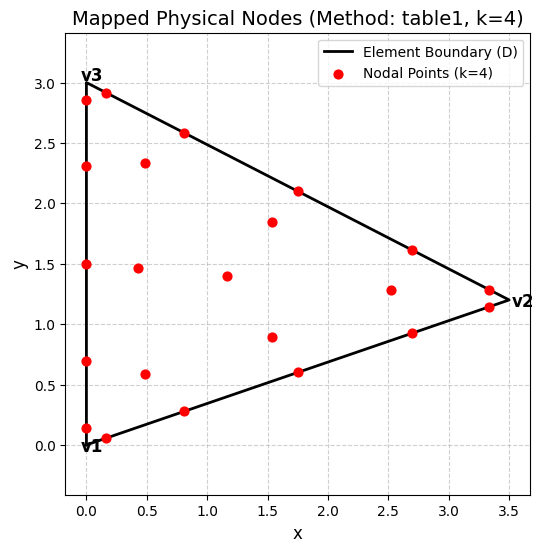

In [4]:
import matplotlib.pyplot as plt

# 設定繪圖大小
plt.figure(figsize=(6, 6))

# 1. 繪製由 v1, v2, v3 構成的物理三角形邊界
# 為了讓邊界封閉，我們將頂點順序設為 v1 -> v2 -> v3 -> v1
triangle_x = [v1[0], v2[0], v3[0], v1[0]]
triangle_y = [v1[1], v2[1], v3[1], v1[1]]
plt.plot(triangle_x, triangle_y, 'k-', linewidth=2, label='Element Boundary (D)')

# 2. 繪製映射後的內部與邊界節點 (x, y)
plt.scatter(x, y, c='red', s=40, zorder=5, label=f'Nodal Points (k={k})')

# 標註三個頂點的位置
plt.text(v1[0] - 0.05, v1[1] - 0.05, 'v1', fontsize=12, fontweight='bold')
plt.text(v2[0] + 0.02, v2[1] - 0.05, 'v2', fontsize=12, fontweight='bold')
plt.text(v3[0] - 0.05, v3[1] + 0.02, 'v3', fontsize=12, fontweight='bold')

# 設定圖表格式
plt.title(f"Mapped Physical Nodes (Method: {method}, k={k})", fontsize=14)
plt.xlabel("x", fontsize=12)
plt.ylabel("y", fontsize=12)
plt.grid(True, linestyle='--', alpha=0.6)
plt.axis('equal') # 確保 x 軸與 y 軸比例一致，三角形才不會變形
plt.legend()

# 顯示圖表
plt.show()

In [5]:
Fx, Fy = F_vector(x, y)
error = compute_divergence(Fx, Fy, factors, D_xi, D_eta) - divF_exact(x, y)
print("Max error in divergence:", np.max(np.abs(error)))

Max error in divergence: 1.1368683772161603e-13
